In [1]:
# directory - till parquet file (/projects)
# read parquet file
# Data handling
import os
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from datetime import timedelta
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans


import itertools

In [2]:
# merged TIF would be nice
# Nan, 30 second will be done (show how many 30sec jobs exists, and execution time distribution)
# a plot that shows execution time as bins on x-axis, and y axis is the #of jobs
# 30sec, 2mins, 10mins, 30mins, 1hr, 2hr, .. --> max execution time too
# you can check these from "cpu_util_timestamp" -- or mem_util_timestamp, gpu_util_timestamp in arrays
# use better colors for the graphs - cm muted python

# ---- Global style ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Reading The Big M100 Timeseries Parquet File

In [3]:
new_dir = "/projectnb/peaclab-mon/boztop/temporal_modeling_trials/big_m100_timeseries.parquet"

new_dir_df = pd.read_parquet(
    new_dir,
    columns=["user_id", "job_id", "partition","job_state", "start_time", "end_time","cpu_util_pct", "gpu_util_pct","mem_util_pct" ]
)


In [4]:
print(len(new_dir_df))

160798


In [5]:
new_dir_df.head()

,user_id,job_id,partition,job_state,start_time,end_time,cpu_util_pct,gpu_util_pct,mem_util_pct
0,2,13577,1,COMPLETED,2022-09-04 01:41:59+00:00,2022-09-04 10:08:52+00:00,"[58.343057176196034, 58.343057176196034, 58.34...","[92.41540256709452, 92.41540256709452, 92.4154...","[70.82448038214703, 70.82448038214703, 70.8244..."
1,2,13896,1,COMPLETED,2022-09-17 23:24:56+00:00,2022-09-18 07:36:45+00:00,"[66.2777129521587, 64.53471411901984, 64.45449...","[94.60326721120187, 92.03617269544924, 91.9194...","[79.93534130688448, 78.11818297841307, 78.0628..."
2,2,16217,1,COMPLETED,2022-09-13 03:14:45+00:00,2022-09-13 04:29:01+00:00,"[65.03132284382285, 65.03132284382285, 65.0313...","[95.33799533799534, 95.33799533799534, 95.3379...","[76.92158908799534, 76.92158908799534, 76.9215..."
3,2,22189,1,COMPLETED,2022-09-10 01:55:26+00:00,2022-09-10 10:24:59+00:00,"[61.43507638072855, 61.43507638072855, 61.4350...","[95.79905992949472, 95.79905992949472, 95.7990...","[74.14589453584018, 74.14589453584018, 74.1458..."
4,2,51814,1,COMPLETED,2022-09-13 04:04:33+00:00,2022-09-13 05:17:36+00:00,"[65.35183566433567, 65.39554195804196, 65.3518...","[95.48368298368298, 95.54195804195804, 95.4836...","[77.24993261946386, 77.25639750874126, 77.2499..."


In [6]:
new_dir_df["job_state"].value_counts()


job_state
FAILED           92878
COMPLETED        59762
TIMEOUT           4069
CANCELLED         3492
OUT_OF_MEMORY      520
PREEMPTED           64
NODE_FAIL           13
Name: count, dtype: int64

# Adding The Duration Of Jobs As A Column

In [7]:
# ensure datetime
new_dir_df["start_time"] = pd.to_datetime(new_dir_df["start_time"])
new_dir_df["end_time"] = pd.to_datetime(new_dir_df["end_time"])

# duration in seconds
new_dir_df["duration_sec"] = (
    new_dir_df["end_time"] - new_dir_df["start_time"]
).dt.total_seconds()

In [8]:
new_dir_df.head()

,user_id,job_id,partition,job_state,start_time,end_time,cpu_util_pct,gpu_util_pct,mem_util_pct,duration_sec
0,2,13577,1,COMPLETED,2022-09-04 01:41:59+00:00,2022-09-04 10:08:52+00:00,"[58.343057176196034, 58.343057176196034, 58.34...","[92.41540256709452, 92.41540256709452, 92.4154...","[70.82448038214703, 70.82448038214703, 70.8244...",30413.0
1,2,13896,1,COMPLETED,2022-09-17 23:24:56+00:00,2022-09-18 07:36:45+00:00,"[66.2777129521587, 64.53471411901984, 64.45449...","[94.60326721120187, 92.03617269544924, 91.9194...","[79.93534130688448, 78.11818297841307, 78.0628...",29509.0
2,2,16217,1,COMPLETED,2022-09-13 03:14:45+00:00,2022-09-13 04:29:01+00:00,"[65.03132284382285, 65.03132284382285, 65.0313...","[95.33799533799534, 95.33799533799534, 95.3379...","[76.92158908799534, 76.92158908799534, 76.9215...",4456.0
3,2,22189,1,COMPLETED,2022-09-10 01:55:26+00:00,2022-09-10 10:24:59+00:00,"[61.43507638072855, 61.43507638072855, 61.4350...","[95.79905992949472, 95.79905992949472, 95.7990...","[74.14589453584018, 74.14589453584018, 74.1458...",30573.0
4,2,51814,1,COMPLETED,2022-09-13 04:04:33+00:00,2022-09-13 05:17:36+00:00,"[65.35183566433567, 65.39554195804196, 65.3518...","[95.48368298368298, 95.54195804195804, 95.4836...","[77.24993261946386, 77.25639750874126, 77.2499...",4383.0


# Stats For Duration Column

In [9]:
stats = {
    "min": new_dir_df["duration_sec"].min(),
    "max": new_dir_df["duration_sec"].max(),
    "mean": new_dir_df["duration_sec"].mean(),
    "std": new_dir_df["duration_sec"].std()
}

print(stats)

{'min': 0.0, 'max': 623731.0, 'mean': 6535.7087401584595, 'std': 19366.711730339295}


In [10]:
bins = [
    0,          # start
    30,         # 30 sec
    120,        # 2 min
    600,        # 10 min
    1800,       # 30 min
    3600,       # 1 hour
    18000,      # 5 hour
    180000,     # 50 hour
    360000,     # 100 hour
    540000,     # 150 hour
    np.inf      # 150+ hour
]

labels = [
    "0-30s",
    "30s-2min",
    "2-10min",
    "10-30min",
    "30min-1hr",
    "1-5hr",
    "5-50hr",
    "50-100hr",
    "100-150hr",
    "150hr+"
]

new_dir_df["duration_bin"] = pd.cut(
    new_dir_df["duration_sec"],
    bins=bins,
    labels=labels,
    right=False
)

In [11]:
duration_counts = new_dir_df["duration_bin"].value_counts().sort_index()
print(duration_counts)

duration_bin
0-30s        99229
30s-2min      7156
2-10min      16227
10-30min      8657
30min-1hr     6406
1-5hr         7395
5-50hr       15726
50-100hr         1
100-150hr        0
150hr+           1
Name: count, dtype: int64


In [12]:
print(len(new_dir_df))

160798


# Total Number of Jobs = 160798

# Number Of <30 Second Jobs = 99229

# Number Of >30 Second Jobs = 61569

/scratch/4939318.1.engineering/ipykernel_3650511/1609276941.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("tab20c", len(duration_counts))


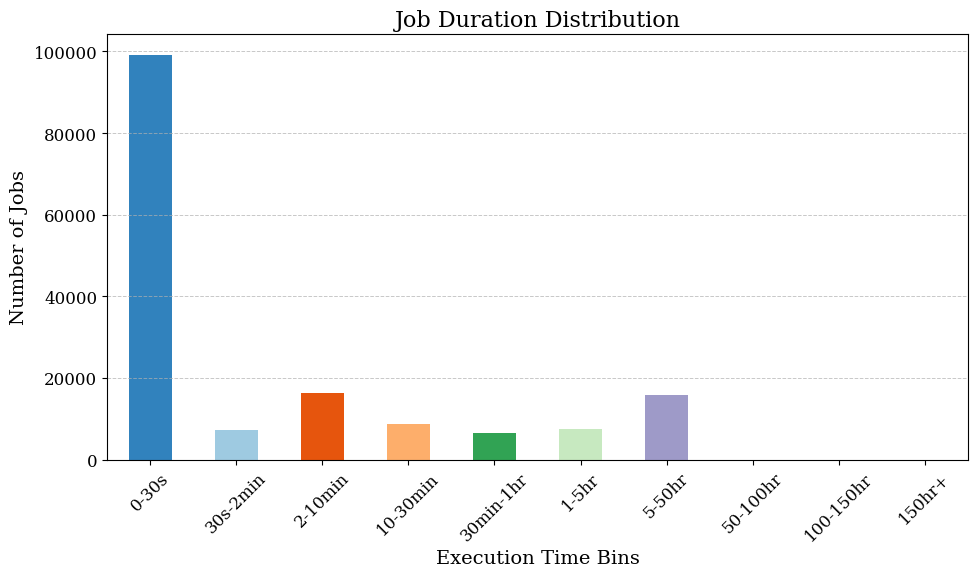

In [13]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

colors = cm.get_cmap("tab20c", len(duration_counts))

plt.figure(figsize=(10, 6))

ax = duration_counts.plot(
    kind="bar",
    color=[colors(i) for i in range(len(duration_counts))]
)

# Labels and title
plt.xlabel("Execution Time Bins")
plt.ylabel("Number of Jobs")
plt.title("Job Duration Distribution")

# Grid
ax.grid(
    True,
    which="major",
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.7
)

# Formatting
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Removing Jobs That Are <30 Seconds

In [14]:
new_dir_df = new_dir_df[new_dir_df["duration_bin"] != "0-30s"]

In [15]:
len(new_dir_df)

61569

In [16]:
new_dir_df['job_state'].value_counts()

job_state
COMPLETED        52180
TIMEOUT           4069
FAILED            3073
CANCELLED         1679
OUT_OF_MEMORY      493
PREEMPTED           62
NODE_FAIL           13
Name: count, dtype: int64

In [17]:
new_dir_df = new_dir_df[new_dir_df['job_state']=='COMPLETED']


# Removing Nan, inf and -inf Values

In [18]:
def count_valid(u):
    u = np.array(u, dtype=float)
    return np.sum(np.isfinite(u))  # count of valid values

def count_total(u):
    return len(u)

In [19]:
for col in ["cpu_util_pct", "mem_util_pct", "gpu_util_pct"]:
    new_dir_df[f"{col}_total"] = new_dir_df[col].apply(count_total)
    new_dir_df[f"{col}_valid"] = new_dir_df[col].apply(count_valid)
    new_dir_df[f"{col}_removed"] = (
        new_dir_df[f"{col}_total"] - new_dir_df[f"{col}_valid"]
    )

In [20]:
for col in ["cpu_util_pct", "mem_util_pct", "gpu_util_pct"]:
    removed = new_dir_df[f"{col}_removed"].sum()
    print(f"{col}: {removed} values have nan/inf values")

cpu_util_pct: 280 values have nan/inf values
mem_util_pct: 280 values have nan/inf values
gpu_util_pct: 280 values have nan/inf values


In [21]:
def clean_array(u):
    u = np.array(u, dtype=float)
    return u[np.isfinite(u)]

# clean all three resource columns
for col in ["cpu_util_pct", "mem_util_pct", "gpu_util_pct"]:
    new_dir_df[col] = new_dir_df[col].apply(clean_array)

# keep only rows where all three cleaned arrays are non-empty
mask = (
    new_dir_df["cpu_util_pct"].apply(len) > 0
) & (
    new_dir_df["mem_util_pct"].apply(len) > 0
) & (
    new_dir_df["gpu_util_pct"].apply(len) > 0
)

before = len(new_dir_df)
new_dir_df = new_dir_df[mask].copy()
after = len(new_dir_df)

print("Rows removed:", before - after)
print("Rows remaining:", after)

Rows removed: 82
Rows remaining: 52098


# Final Rows Remaining - 52098

# Computing TIF Values

In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

try:
    from tsfresh.feature_extraction.feature_calculators import mean_abs_change
    TSFRESH_OK = True
except ImportError:
    TSFRESH_OK = False


def compute_tif_metrics(u):
    u = np.array(u, dtype=float)

    mu = np.mean(u)
    sd = np.std(u, ddof=0)
    cv = sd / mu if mu != 0 else np.nan

    x = np.arange(len(u))
    x_mean = np.mean(x)
    u_mean = np.mean(u)

    denom = np.sum((x - x_mean) ** 2)
    slope = np.sum((x - x_mean) * (u - u_mean)) / denom if denom != 0 else 0.0
    trend = abs(slope)

    mac = np.mean(np.abs(np.diff(u))) if len(u) > 1 else 0.0

    return pd.Series({
        "cv": cv,
        "trend": trend,
        "mac": mac
    })

In [24]:
resources = ["cpu", "mem", "gpu"]

for r in resources:
    metrics = new_dir_df[f"{r}_util_pct"].apply(compute_tif_metrics)
    metrics.columns = [f"{r}_tif_cv", f"{r}_tif_trend", f"{r}_tif_mac"]
    new_dir_df = pd.concat([new_dir_df, metrics], axis=1)

In [25]:
#normalizing the tif values
def _minmax(s: pd.Series) -> pd.Series:
    mn = s.min(skipna=True)
    mx = s.max(skipna=True)
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.nan, index=s.index)
    return (s - mn) / (mx - mn)

resources = ["cpu", "mem", "gpu"]
metrics = ["cv", "mac", "trend"]

for r in resources:
    for m in metrics:
        col = f"{r}_tif_{m}"
        norm_col = f"{r}_tif_{m}_norm"
        new_dir_df[norm_col] = _minmax(new_dir_df[col])

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
#calculating merged tif
for r in resources:
    new_dir_df[f"{r}_merged_tif"] = (
        0.4 * new_dir_df[f"{r}_tif_cv_norm"] +
        0.4 * new_dir_df[f"{r}_tif_mac_norm"] +
        0.2 * new_dir_df[f"{r}_tif_trend_norm"]
    )

# TIF Distribution

In [26]:
def plot_tif_distribution(df, colname, bin_width=0.02):
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 14,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12
    })

    vals = df[colname].values
    vals = vals[np.isfinite(vals)]
    
    total = len(df[colname])
    valid = np.sum(np.isfinite(df[colname]))
    print(f"{colname}: {total - valid} NaN/inf values ignored in plot")

    # uniform bins
    bins = np.arange(0, 1 + bin_width, bin_width)

    # phase masks
    phases = {
        "CONSTANT": (vals >= 0.0) & (vals < 0.2),
        "PHASED":   (vals >= 0.2) & (vals < 0.4),
        "DYNAMIC":  (vals >= 0.4) & (vals < 0.6),
        "SPORADIC": (vals >= 0.6)
    }

    phase_colors = {
        "CONSTANT": "#1f77b4",  # blue
        "PHASED": "#ffdd57",    # soft yellow
        "DYNAMIC": "#2ca02c",   # green
        "SPORADIC": "#d62728"   # red
    }

    plt.figure(figsize=(10, 6))

    for label, mask in phases.items():
        phase_vals = vals[mask]

        if len(phase_vals) == 0:
            continue

        plt.hist(
            phase_vals,
            bins=bins,
            color=phase_colors[label],
            edgecolor="black",
            label=label,
            alpha=0.9
        )

    for x in [0.2, 0.4, 0.6]:
        plt.axvline(x, linestyle="--", linewidth=1.5, color="gray")
    
    display_name = colname.replace("_", " ").title()
    
    plt.yscale("log")
    plt.xlabel(display_name)
    plt.ylabel("Number of Jobs (log)")
    plt.title(f"{display_name} distribution")

    plt.legend()
    plt.tight_layout()
    plt.show()

In [27]:
plot_tif_distribution(new_dir_df, "cpu_merged_tif")
plot_tif_distribution(new_dir_df, "mem_merged_tif")
plot_tif_distribution(new_dir_df, "gpu_merged_tif")

KeyError: 'cpu_merged_tif'

In [ ]:
plot_tif_distribution(new_dir_df, "cpu_tif_cv_norm")
plot_tif_distribution(new_dir_df, "mem_tif_cv_norm")
plot_tif_distribution(new_dir_df, "gpu_tif_cv_norm")

In [28]:
# DTW dynamic time warping --> find ditsance between time series
# DTW pairwise --> clustering

# sustained underutilization window 

In [30]:
new_dir_df['user_id'].value_counts()

user_id
101     6670
844     4682
1234    3957
748     3668
1422    1967
        ... 
218        1
216        1
1499       1
182        1
1742       1
Name: count, Length: 379, dtype: int64

In [31]:
user_101_df = new_dir_df[new_dir_df["user_id"] == 101].copy()

In [32]:
base_path = "/projectnb/peaclab-mon/nishtha/datasets/final_m100_22-9"

new_dir_df.to_parquet(f"{base_path}/big_m100_filtered_jobs.parquet", index=False)
user_101_df.to_parquet(f"{base_path}/user_101_jobs.parquet", index=False)